# CommonRoad-io 
## Separate RoadNetwork and ObstaclePlanningProblem

This tutorial shows how CommonRoad XML-files can be separated into **roadNetwork** and **obstaclePlanningProblem** XML-files. To start with, a CommonRoad XML-file consists of a **Scenario** and a **PlanningProblemSet**:
* A **Scenario** represents the environment including a **LaneletNetwork** and a set of **DynamicObstacle** and **StaticObstacle**.
    * A **LaneletNetwork** is built from lane segments (**Lanelet**), that can be connected arbitrarily.
* A **PlanningProblemSet** contains one **PlanningProblem** for every ego vehicle in the **Scenario**, consisting of an **initial position** and a **GoalRegion** that has to be reached.

## 0. Preparation
* Before you proceed any further, make sure you have skimmed through [CommonRoad API](https://commonroad-io.readthedocs.io/en/latest/api/) to gain an overall view of the functionalities provided by CommonRoad modules. You may need to refer to it for implementation details throughout this tutorial.

* Additional documentations on **CommonRoad XML format, Cost Functions, Vehicle Models, etc.** can be found at [CommonRoad](https://commonroad.in.tum.de/) on the specific tool pages.

## 1. Read XML file

As documented in [CommonRoadFileReader](https://commonroad-io.readthedocs.io/en/latest/api/common/#module-commonroad.common.file_reader), the **CommonRoadFileReader** reads in a CommonRoad XML file, and its **open()** method returns a **Scenario** and a **PlanningProblemSet** object:

#lanelets =  3

position= ShapeGroup: 
	 number of shapes: 1 

orientation= Interval
start: -1.0491
end: 0.95091

time_step= Interval
start: 35
end: 40




/home/yipyip/Desktop/workspace/miniconda3/envs/cmrio/lib/python3.6/site-packages/commonroad/geometry/shape.py:314: ShapelyDeprecationWarning: Setting custom attributes on geometry objects is deprecated, and will raise an AttributeError in Shapely 2.0
  self.lanelet_id = lanelet_id


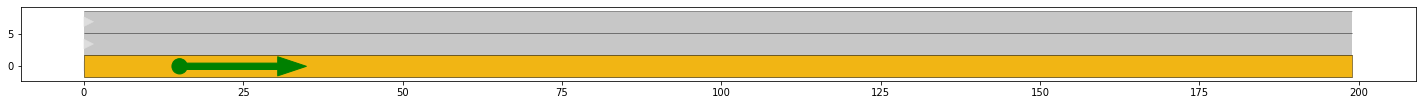

In [1]:
import os
import matplotlib.pyplot as plt
from IPython import display

# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

# generate path of the file to be opened
file_path = "./test/ZAM_Tutorial-1_2_T-1.xml"

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()
print(planning_problem_set.planning_problem_dict[100].goal.state_list[0])

## 2. Write XML file
A key defining two different XML-file (roadNetwork and obstaclesPlanning) needs to be plugged into function **write_to_file()**. When key is None, FileWriter generates one scenario containing roadNetwork and obstaclesPlanning. The XML-file of roadNetwork is renamed "CountryId_MapName-MapId_roadNetwork.xml".

In [2]:
# import necesary classes from different modules
from commonroad.common.file_writer import CommonRoadFileWriter
from commonroad.common.file_writer import OverwriteExistingFile
from commonroad.scenario.scenario import Location
from commonroad.scenario.scenario import Tag
import re
import copy

author = 'Max Mustermann'
affiliation = 'Technical University of Munich, Germany'
source = ''
tags = {Tag.CRITICAL, Tag.INTERSTATE}

scenario_ = copy.deepcopy(scenario)
fw = CommonRoadFileWriter(scenario_, planning_problem_set, author, affiliation, source, tags)

out_path = './output/'
filename = out_path + re.split('/', file_path)[-1]

# generate only one scenario for road or obsPlan 
#fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True, key="road")
#fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True, key="obs")

# default: generate one scenario for road and one for obsPlan
#fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True)

## 3. Visualize XML-file

#lanelets =  3
#lanelets =  0
0

position= ShapeGroup: 
	 number of shapes: 0 

orientation= Interval
start: -1.0491
end: 0.9509

time_step= Interval
start: 35
end: 40




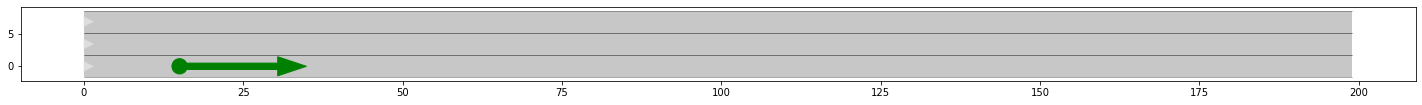

In [4]:
import os
import matplotlib.pyplot as plt
from IPython import display
import re

# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

file_path2 = filename

if '-' in file_path:
    sub_ids = re.split('-', file_path2)
    sec_ids = re.split('_', sub_ids[-2])
    file_path1 = sub_ids[0] + '-' + sec_ids[0] + ".xml"
else:
    file_path1 = os.path.splitext(file_path2)[0] + "_road.xml"

file_path3 = file_path

# read road and obsPlan in version 3.0
scenario1, planning_problem_set1 = CommonRoadFileReader(file_path1, key="road").open()
scenario2, planning_problem_set2 = CommonRoadFileReader(file_path2).open()

# read original file in version 2020a/2018b
#scenario3, planning_problem_set3 = CommonRoadFileReader(file_path3).open()

# plot the scenario for each time step
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    scenario1.draw(rnd, draw_params={'time_begin': i})
    planning_problem_set1.draw(rnd)
    scenario2.draw(rnd, draw_params={'time_begin': i})
    planning_problem_set2.draw(rnd)
    #scenario3.draw(rnd, draw_params={'time_begin': i})
    #planning_problem_set3.draw(rnd)
    rnd.render()
print(len(scenario2.lanelet_network.lanelets))
print(planning_problem_set2.planning_problem_dict[100].goal.state_list[0])